In [1]:
from qiskit.transpiler import CouplingMap

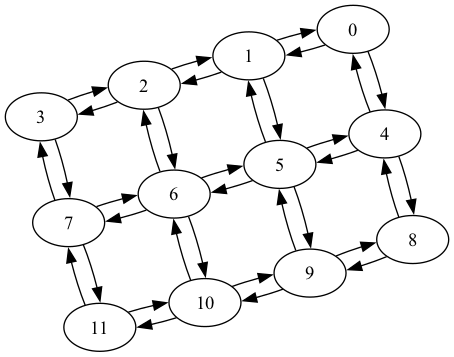

In [34]:
cm = CouplingMap.from_grid(3, 4)
cm.draw()

In [ ]:
import rustworkx as rx
from rustworkx.visit import BFSVisitor, StopSearch

class _KNodeCollector(BFSVisitor):
    def __init__(self, k: int):
        super().__init__()
        self.k = k
        self.collected = []

    def discover_vertex(self, node_index):
        print('Adding {} to collected'.format(node_index))
        self.collected.append(node_index)
        if len(self.collected) >= self.k:
            raise StopSearch

g = cm.graph.to_undirected()
collector = _KNodeCollector(4)
rx.graph_bfs_search(g, [0], collector)

Adding 0 to collected
Adding 1 to collected
Adding 4 to collected
Adding 2 to collected


In [28]:
collector.collected

[0, 1, 2, 3]

In [32]:
cm.size()

10

In [43]:
def _pick_connected_nodes(g: rx.PyGraph, start_node: int, k: int) -> list[int]:
    """Pick k connected nodes from the coupling graph (rustworkx.PyGraph instance)."""
    if k <= 0:
        return []
    elif k > g.num_nodes():
        raise ValueError("k must be less than or equal to the number of nodes in the graph.")
    elif k == g.num_nodes():
        return list(range(g.num_nodes()))
    else:
        class _KNodeCollector(rx.visit.BFSVisitor):
            def __init__(self, k: int):
                super().__init__()
                self.k = k
                self.nodes = []  # node indices

            def discover_vertex(self, v):
                self.nodes.append(v)
                if len(self.nodes) >= self.k:
                    raise rx.visit.StopSearch
        
        collector = _KNodeCollector(k)
        rx.graph_bfs_search(g, [start_node], collector)
        if len(collector.nodes) < k:
            raise ValueError("The graph is not connected enough to collect k nodes.")
        return collector.nodes

In [46]:
_pick_connected_nodes(cm.graph.to_undirected(), 0, 9)

[0, 1, 4, 2, 5, 8, 3, 6, 9]

In [12]:
visit.BFSVisitor

rustworkx.visit.BFSVisitor